# Введение в регрессию 2
Logit, Probit модели

In [1]:
# Подключим нужные для базовых операций библиотеки
import seaborn as sb
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Подключим пакеты для использования OLS метода и тестов
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# Подгрузим полезные функции
from utils import *

# Сделаем автоподгрузку всех изменений при перепрогонке ячейки
%load_ext autoreload
%autoreload 2

## 2. Logit модель на датасете [Heart Disease Health Indicators Dataset](https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset/data)
В данной секции примедена демонстрация применения Logit модели для классификации пациентов на более и менее склонных иметь сердечные заболевания

In [7]:
# Подгрудаем датасет
heart_deaseases_dt = pd.read_csv('/Users/katiegalaeva/exp1/shad/math_13/heart_disease_health_indicators_BRFSS2015.csv')
display(heart_deaseases_dt)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,0.0,1.0,1.0,1.0,18.0,0.0,0.0,2.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


Давайте обучим Logit модель на этом датасете. Без валидации, предполагая, что весь датасет - это наш train датасет.
Для демонстрации работы скрипта я буду использовать только первые 5 колонок + Возрастную группу (Age). В домашней работе вам будет необходимо взять все колонки.

/Users/katiegalaeva/miniconda3/envs/env_01/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 ================================================== TRAIN RESULTS ================================================== 

ROC AUC score: 0.841

              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84    229787
         1.0       0.24      0.80      0.37     23893

    accuracy                           0.74    253680
   macro avg       0.61      0.77      0.60    253680
weighted avg       0.90      0.74      0.79    253680



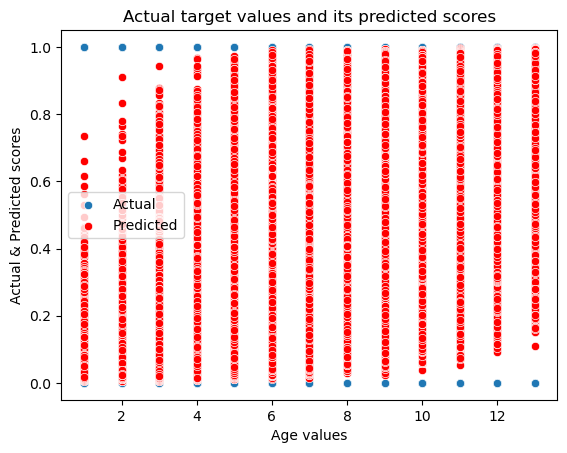

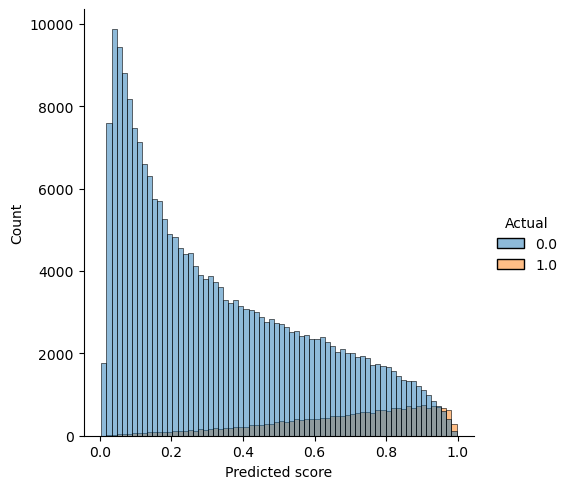

Predicted,0.000000,1.000000
Actual,,
0.000000,169127,60660
1.000000,4882,19011


In [9]:
feature_names = [col for col in heart_deaseases_dt.columns if col != 'HeartDiseaseorAttack']
dt_logit, model_logit = train_binary(
    heart_deaseases_dt, 
    target='HeartDiseaseorAttack',
    feature_names=feature_names,
    plot_feature='Age', 
    model_type='logit', 
    pkg='sklearn',
    class_weight='balanced' 
)

## ВЫВОДЫ
### 2. 

ROC AUC = 0.841. Значение ROC AUC близкое к 1 указывает на то, что модель в целом хорошо разделяет два класса при разных порогах классификации. Это говорит о достаточно хорошей дискриминационной способности модели.

Класс 0.
Precision = 0.97 говорит о том, что среди всех предсказанных моделью «здоровых» 97% действительно здоровы.
Recall = 0.74 - модель правильно находит 74% из всех реальных «здоровых».
F1 = 0.84: отражает сбалансированность precision и recall для класса 0.

Класс 1. 
Precision = 0.24 говорит о том, что среди всех предсказанных «больных» только 24% действительно больны. То есть много ложных предсказаний.
Recall = 0.80 - модель находит 80% реальных больных, что хорошо с точки зрения не пропустить заболевание.
F1 = 0.37 - относительно низкое значение, отражающее дисбаланс между precision и recall.

Accuracy = 0.74: модель верно классифицирует 74% наблюдений. Однако при сильно несбалансированных классах (когда «здоровых» гораздо больше, чем «больных») высокая accuracy может не всегда отражать реальную полезность модели.

Macro avg (precision = 0.61, recall = 0.77, f1 = 0.60). Поскольку классы несбалансированы, усреднение «macro» показывает, что в среднем по двум классам показатели заметно снижаются, особенно precision и f1.
Особенности в контексте применения

Таким образом, модель обладает хорошей способностью отделять здоровых от больных, однако при текущем пороге классификации наблюдается низкий precision для больных.

Если в задаче критично не пропустить ни одного больного (важен высокий recall), то текущая модель может подойти, но придется сталкиваться с большим количеством ложных показаний. Однако, если же ложноположительные случаи стоят дорого (например, требуют дорогостоящих процедур), стоит рассмотреть либо смещение порога, либо использовать методы resamplimg и др.


### 3 Если бы за 1 месяц к вам на осмотр пришло 100 человек и вы ставили диагноз «склонность к сердечным болезням» только по модели, то в среднем скольким из них вы бы поставили диагноз корректно, ошибочно, скольких потенциальных больных упустили? Как вы считаете, насколько полученная вами модель хороша для применения на практике для определения склонных к заболеваниям пациентов?

Корректно было бы поставлено примерно 7, упустили потенциально больных 2 и ошибочно 24.






